In [12]:
import os
import numpy as np
import pandas as pd

from tqdm import tqdm

%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['norm', 'f']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [13]:
from functions.function import Forrester, Schwefel, Higdon, GrammacyLee, Sigmoid, Ackley, Langermann, Griewank, Levy1D, Eggholder1D, Bukin1D, Michalewicz1D

from interval_builder import IntervalBuilder
from envelope_builder import piecewise_envelopes
from samplers.adaptive_sampler import AdaptiveSampler

In [14]:
RANDOM_SEED = 0
# ---------------------------
# Baseline samplers
# ---------------------------
from scipy.stats import qmc
def sample_random(n: int, seed: int) -> np.ndarray:
    r = np.random.RandomState(seed)
    return DOMAIN[0] + r.rand(n,1) * (DOMAIN[1] - DOMAIN[0])

def sample_sobol(n: int, seed: int) -> np.ndarray:
    eng = qmc.Sobol(d=1, scramble=True, seed=seed)
    m = int(np.ceil(np.log2(max((2,n)))))
    pts = eng.random_base2(m=m)[:n,:]
    return DOMAIN[0] + pts * (DOMAIN[1] - DOMAIN[0])

def sample_lhs(n: int, seed: int) -> np.ndarray:
    eng = qmc.LatinHypercube(d=1, seed=seed)
    pts = eng.random(n)
    return DOMAIN[0] + pts * (DOMAIN[1] - DOMAIN[0])

def sample_grid(n: int, seed: int):
    return np.linspace(DOMAIN[0], DOMAIN[1], n).reshape((-1,1))

# ---------------------------
# Models: GP, Improved MLP (Fourier ensemble), RF
# ---------------------------
import torch
import torch.nn as nn

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

def fit_rf(X, y):
    rf = RandomForestRegressor(n_estimators=350, random_state=RANDOM_SEED)
    rf.fit(X, y.ravel()); return rf

def fourier_features(x_raw: np.ndarray, K: int = 12) -> np.ndarray:
    a, b = DOMAIN
    x = (x_raw - a) / (b - a)
    feats = [x, x**2, x**3, x**4]
    for k in range(1, K+1):
        feats.append(np.sin(2*np.pi*k*x))
        feats.append(np.cos(2*np.pi*k*x))
    return np.column_stack(feats)

# --- 4. Define the MLP Model ---
class TorchMLP(nn.Module):
    def __init__(self):
        super(TorchMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

class ImprovedMLP:
    def __init__(self, K=12, n_ensemble=5, seed=RANDOM_SEED):
        self.K = K
        self.n_ens = n_ensemble
        self.seed = seed
        self.scaler_X = StandardScaler(with_mean=False)
        self.scaler_y = StandardScaler()
        self.models = []

    def fit(self, X, y):
        Phi = fourier_features(X, self.K)
        self.scaler_X.fit(Phi)
        Phi_s = self.scaler_X.transform(Phi)
        y_s = self.scaler_y.fit_transform(y.reshape(-1,1)).ravel()
        self.models = []
        for i in range(self.n_ens):
            mlp = MLPRegressor(hidden_layer_sizes=(256,256,256), activation="relu",
                               solver="adam", learning_rate_init=1.5e-3, alpha=1e-4,
                               max_iter=9000, early_stopping=False, n_iter_no_change=500,
                               validation_fraction=0.2, random_state=self.seed + i)
            mlp.fit(Phi_s, y_s)
            self.models.append(mlp)
        return self

    def predict(self, Xq, return_std=False):
        Phi_q = fourier_features(Xq, self.K)
        Phi_qs = self.scaler_X.transform(Phi_q)
        preds = np.column_stack([m.predict(Phi_qs) for m in self.models])
        preds = self.scaler_y.inverse_transform(preds)
        yq_m = preds.mean(axis=1, keepdims=True)
        yq_s = preds.std(axis=1, keepdims=True)
        
        yqm = yq_m.ravel() # self.scaler_y.inverse_transform(yq_m).ravel()
        yqs = yq_s.ravel() #self.scaler_y.inverse_transform(yq_s).ravel()
        
        if return_std:
            return yqm, yqs
        else:
            return yqm
    

In [15]:
def compute_gaps(breakpoints, sample_coarse=False):
    gaps = []
    for idx in range(len(breakpoints) - 1):
        a, b = breakpoints[idx], breakpoints[idx+1]
        mc, m = func.f_mccormick(a, b)
        if sample_coarse:
            lb, ub = compute_bounds_on_expr(mc.pyomo_expr)
            gap = [ub - lb]
        else:
            _, _, _, gap = func.envelope_interval(a, b)
        gaps.append(max(gap))
    return gaps

In [16]:
# OVERALL_BUDGET = 100
# sampling_budget = 0.6

# BUDGET = OVERALL_BUDGET * sampling_budget
# REFINING = OVERALL_BUDGET * (1 - sampling_budget)

def method0_uncertanity(func, sample_coarse=True, return_domains=True, mccormick_sampling=False):
    sampler = AdaptiveSampler(func, BUDGET, False)
    breakpoints = np.linspace(DOMAIN[0], DOMAIN[1], DOMAIN_SPLITS + 1)

    domains = []
    gaps = []
    for idx in range(len(breakpoints) - 1):
        a, b = breakpoints[idx], breakpoints[idx+1]
        mc, m = func.f_mccormick(a, b)
        if sample_coarse:
            lb, ub = compute_bounds_on_expr(mc.pyomo_expr)
            gap = [ub - lb]
        else:
            _, _, _, gap = func.envelope_interval(a, b)
        domains.append((a,b))
        gaps.append(max(gap))
        
    sample_dist = allocate_samples(gaps, BUDGET, MIN_SAMPLES)
    print('Sample Allocations: ', sample_dist)
    sampled_x = []
    for idx in range(len(domains)):
        d1,d2 = domains[idx]
        s = sample_dist[idx]
        if mccormick_sampling:
            samples, _ = sampler.sample_points(domain=domains[idx], points_n=s)
        else:
            if idx > 0:
                samples = np.linspace(d1, d2, s + 1)[1:]
            else:
                samples = np.linspace(d1, d2, s)
        sampled_x.extend(samples)
    sampled_x.sort()
    sampled_x = np.array(sampled_x)
    sampled_y = func.f(sampled_x)
    
    if return_domains:
        return sampled_x, sampled_y, domains, gaps
    else:
        return sampled_x, sampled_y

from typing import List

def allocate_samples(weights: List[float], total_samples: int, min_per_gap: int) -> List[int]:
    """
    Allocate total_samples across gaps proportionally to weights,
    ensuring at least min_per_gap samples for each gap.
    
    Args:
        weights (List[float]): List of weights (e.g., gap sizes).
        total_samples (int): Total number of samples to allocate.
        min_per_gap (int): Minimum samples each gap must receive.
        
    Returns:
        List[int]: Final allocation of samples per gap.
    """
    n = len(weights)
    # Step 1: Assign minimum to each gap
    base_alloc = [min_per_gap] * n
    remaining = total_samples - n * min_per_gap
    
    if remaining < 0:
        raise ValueError("Not enough samples to satisfy minimum requirement for all gaps.")
    
    # Step 2: Normalize weights
    total_weight = sum(weights)
    proportions = [w / total_weight for w in weights]
    
    # Step 3: Proportional allocation
    proportional_alloc = [remaining * p for p in proportions]
    
    # Step 4: Combine and round
    final_alloc = [base + int(round(prop)) for base, prop in zip(base_alloc, proportional_alloc)]
    
    # Step 5: Adjust to ensure sum matches total_samples
    diff = total_samples - sum(final_alloc)
    
    # Distribute remainder (if rounding caused mismatch)
    i = 0
    while diff != 0:
        if diff > 0:
            final_alloc[i % n] += 1
            diff -= 1
        else:
            if final_alloc[i % n] > min_per_gap:
                final_alloc[i % n] -= 1
                diff += 1
        i += 1
    
    return final_alloc

import bisect

def assign_domains(points, domains):
    boundaries = [d[1] for d in domains]
    result = []
    for p in points:
        idx = bisect.bisect_left(boundaries, p)
        if idx == 0:
            d = domains[0]
            if d[0] <= p <= d[1]:
                result.append(idx)
            else:
                result.append(-1)
        elif idx < len(domains):
            d = domains[idx]
            if d[0] < p <= d[1]:
                result.append(idx)
            else:
                result.append(-1)
        else:
            result.append(-1)
    return np.array(result)

In [17]:
FUNCTIONS = {
    "Ackley": {"domain": [-32.768, 32.768], 'f': Ackley},
    "Schwefel": {'domain':[-500, 500], 'f': Schwefel},
    "Sigmoid": {'domain': [-6, 6], 'f': Sigmoid},
    "GramacyLee": {'domain':[0.5, 3.5], 'f': GrammacyLee},
    "Higdon": {'domain': [0, 10], 'f': Higdon},
    "Forrester": {'domain': [0, 2.5], 'f': Forrester},
    "Langermann": {'domain': [-9.99, 20], 'f': Langermann},
    "Griewank": {'domain': [-50, 50], 'f': Griewank},
    "Levy1D": {'domain': [-20, 20], 'f': Levy1D},
    "Eggholder1D": {'domain': [-512, 512], 'f': Eggholder1D},
    "Bukin1D": {'domain': [-15.0, 15.0], 'f': Bukin1D},
    "Michalewicz1D": {'domain': [-10, 10], 'f': Michalewicz1D},
}

selection = 'Langermann'
OVERALL_BUDGET = 100
sampling_budget = 0.5

BUDGET = int(OVERALL_BUDGET * sampling_budget)
REFINING = int(OVERALL_BUDGET * (1 - sampling_budget))


func = FUNCTIONS[selection]['f']()
DOMAIN = FUNCTIONS[selection]['domain']

DOMAIN_SPLITS = 10

MIN_SAMPLES = 1

f = func.f

In [19]:
# gp_ei_skopt.py
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from skopt.acquisition import gaussian_ei  # <-- standard EI

def fit_gp(X, y):
    # A solid default kernel
    kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(1e-6)
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0)
    gp.fit(X, y)
    return gp


Top EI x (GP): [-9.99       10.45431078 10.37914787 10.30398496 10.22882206]


/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [20]:
from scipy.stats import norm


def expected_improvement(mu, std, y_opt=0.0, xi=0.01):
    values = np.zeros_like(mu, dtype=np.float64)
    mask = std > 0
    improve = y_opt - xi - mu[mask]
    scaled = improve / std[mask]
    cdf = norm.cdf(scaled)
    pdf = norm.pdf(scaled)
    exploit = improve * cdf
    explore = std[mask] * pdf
    values[mask] = exploit + explore

    return values

In [21]:
from sklearn.metrics import mean_absolute_percentage_error
from typing import List, Tuple, Callable, Dict

In [23]:
def compute_gaps(breakpoints, sample_coarse=False):
    gaps = []
    for idx in range(len(breakpoints) - 1):
        a, b = breakpoints[idx], breakpoints[idx+1]
        mc, m = func.f_mccormick(a, b)
        if sample_coarse:
            lb, ub = compute_bounds_on_expr(mc.pyomo_expr)
            gap = [ub - lb]
        else:
            _, _, _, gap = func.envelope_interval(a, b)
        gaps.append(max(gap))
    return gaps


  Ackley
  BUDGET: 50 (warm start: 25, refining: 25)
  DOMAIN: [-32.768, 32.768]

  --- N = 5 ---
Sample Allocations:  [2, 4, 12, 4, 3]
  Sample Allocations: [2, 4, 12, 4, 3]
  Gaps: ['2.5015', '5.0061', '16.7775', '5.0061', '2.5015']
  H/Hmax=0.820, N_eff=3.74, rho=0.748, n50=1, n80=3


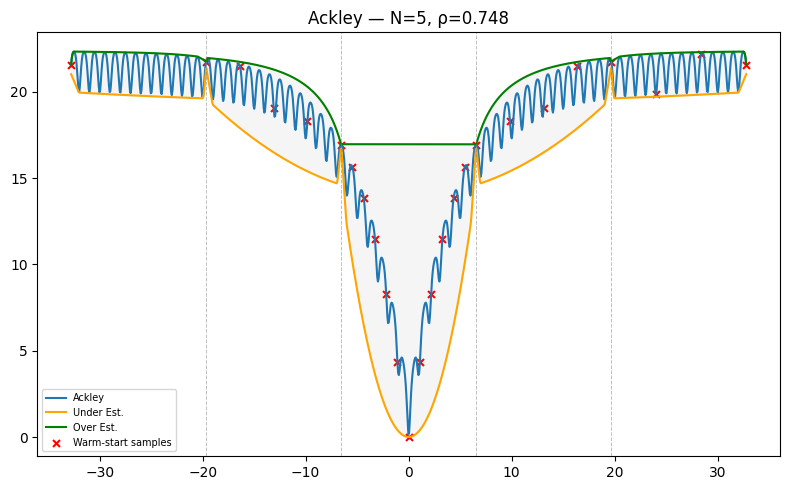

    Strategy: EI
Sample Allocations:  [2, 4, 12, 4, 3]


      EI:   0%|                                                                                          | 0/25 [00:00<?, ?it/s]

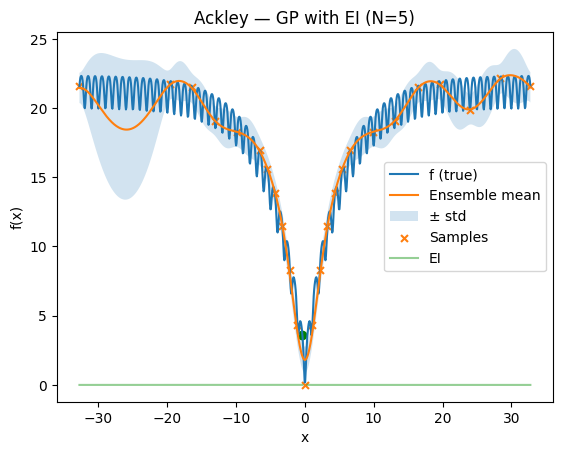

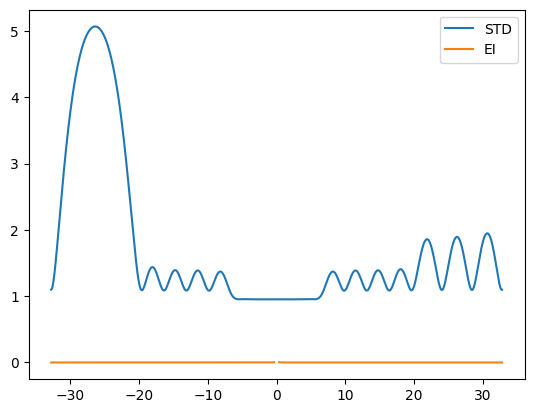

      EI:   4%|███▎                                                                              | 1/25 [00:00<00:09,  2.62it/s]

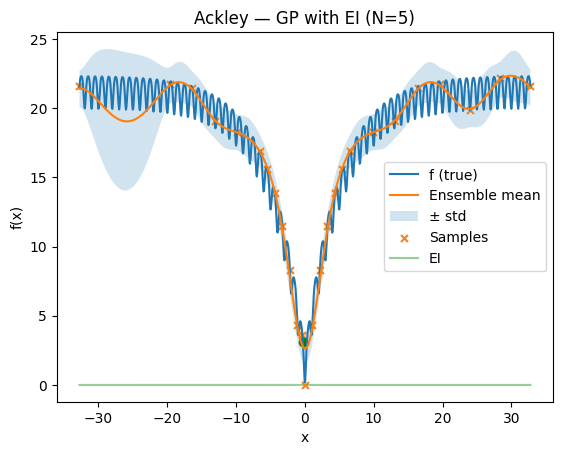

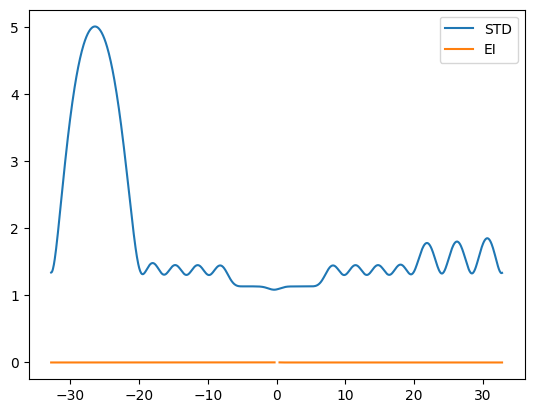

      EI:   8%|██████▌                                                                           | 2/25 [00:00<00:09,  2.34it/s]

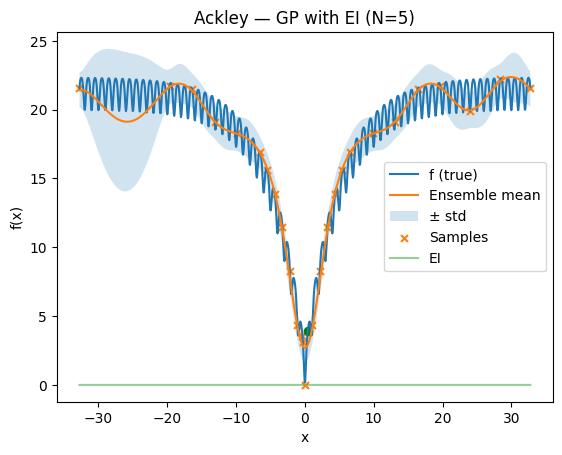

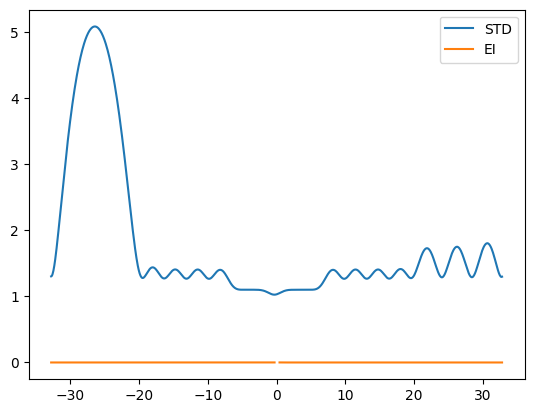

      EI:  12%|█████████▊                                                                        | 3/25 [00:01<00:09,  2.40it/s]

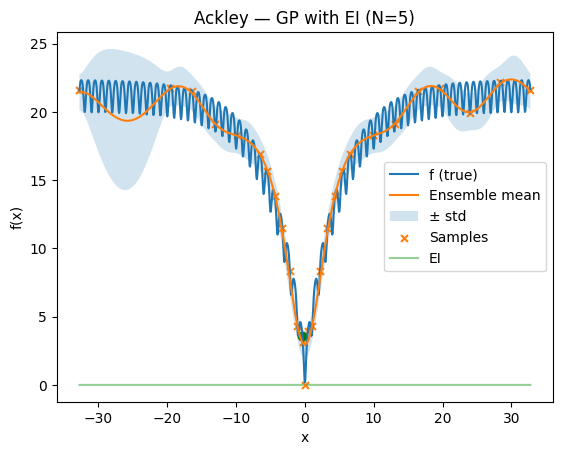

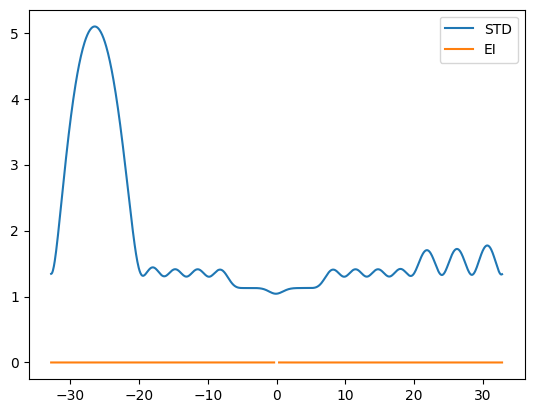

      EI:  16%|█████████████                                                                     | 4/25 [00:01<00:08,  2.42it/s]

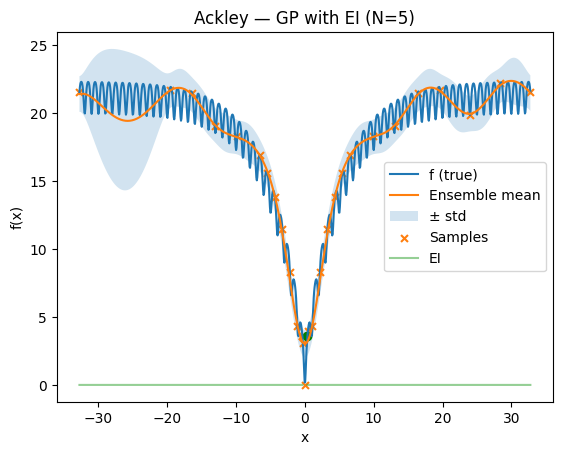

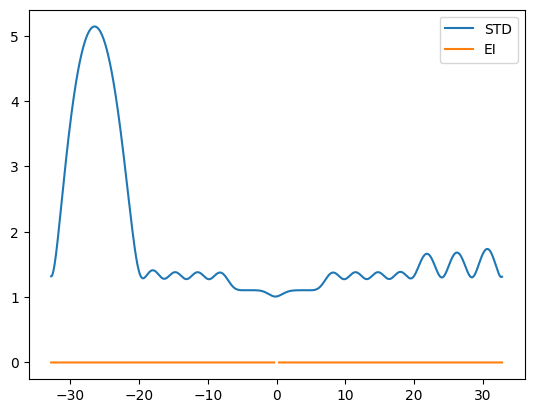

      EI:  20%|████████████████▍                                                                 | 5/25 [00:02<00:08,  2.46it/s]

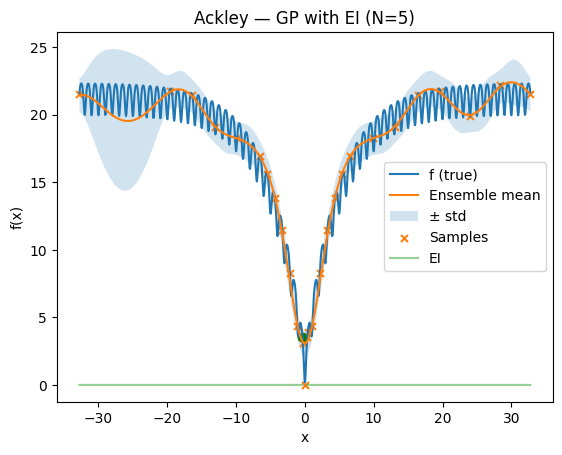

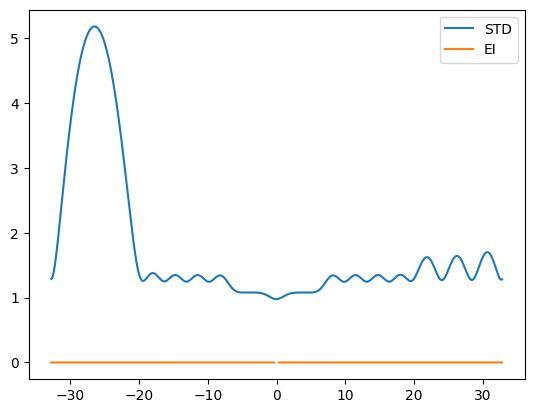

      EI:  24%|███████████████████▋                                                              | 6/25 [00:02<00:07,  2.41it/s]

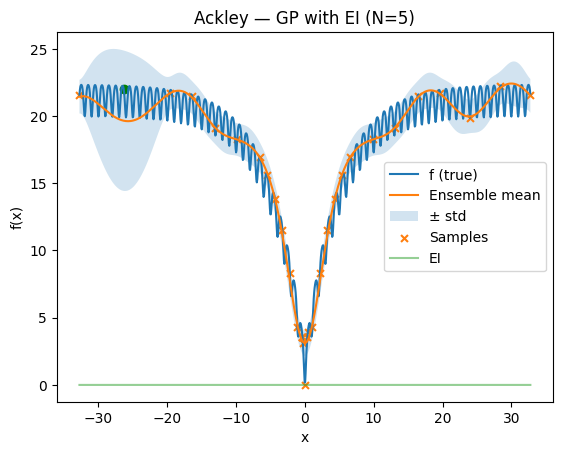

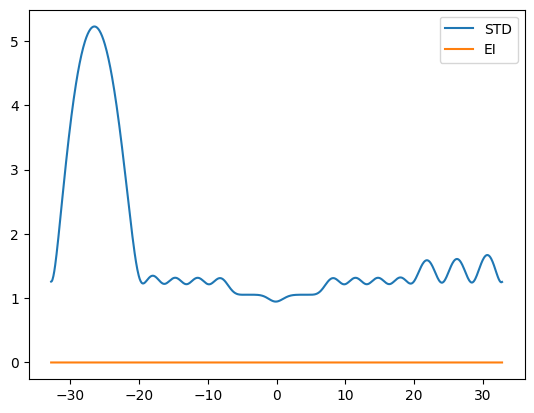

      EI:  28%|██████████████████████▉                                                           | 7/25 [00:02<00:07,  2.30it/s]

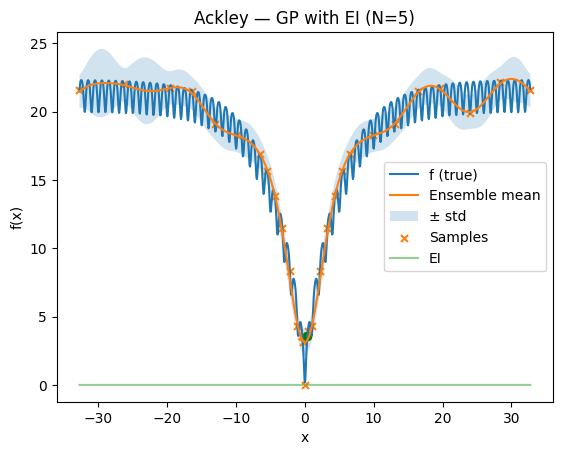

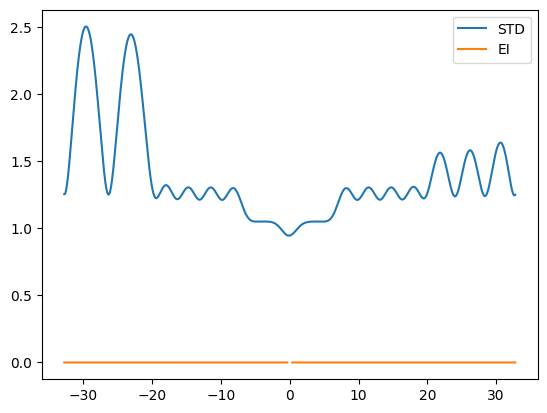

      EI:  32%|██████████████████████████▏                                                       | 8/25 [00:03<00:08,  2.02it/s]

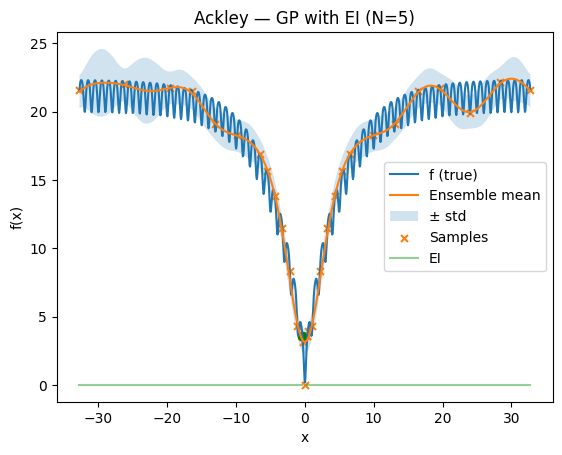

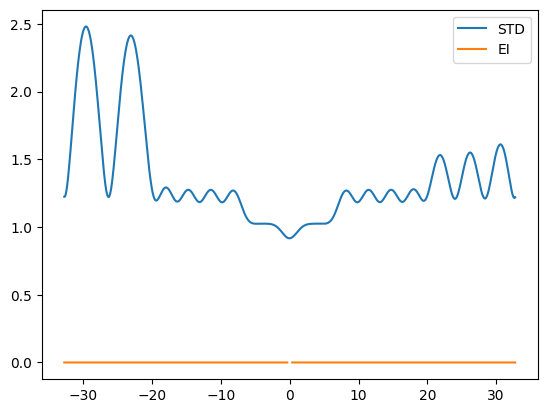

      EI:  36%|█████████████████████████████▌                                                    | 9/25 [00:04<00:08,  1.83it/s]

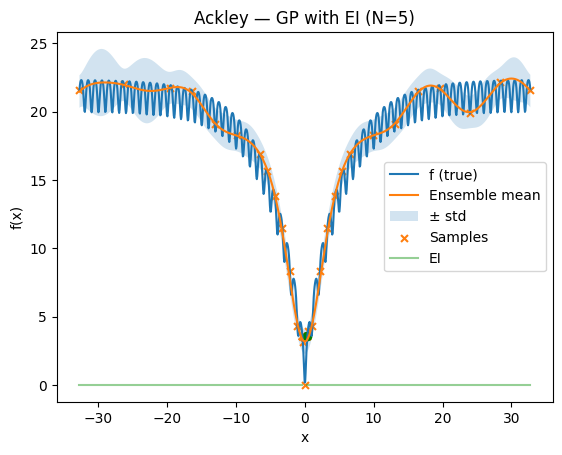

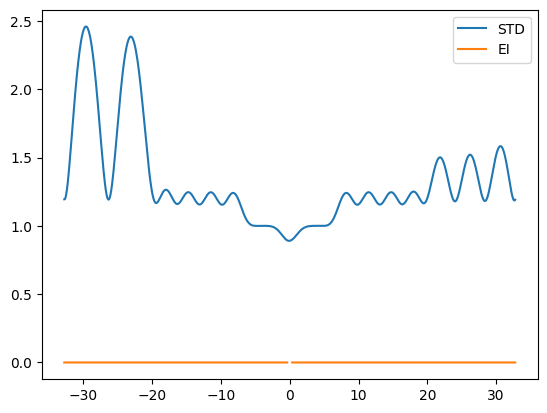

      EI:  40%|████████████████████████████████▍                                                | 10/25 [00:04<00:08,  1.73it/s]

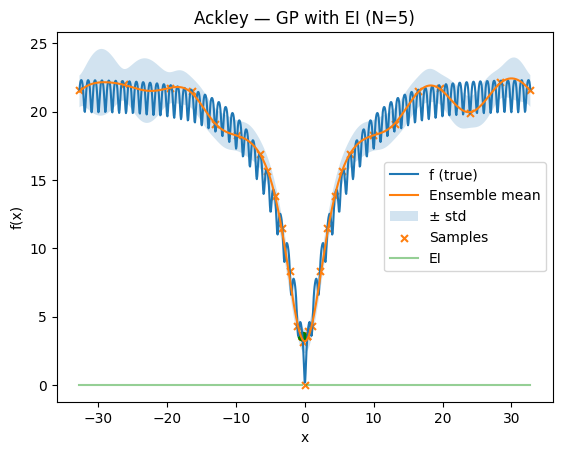

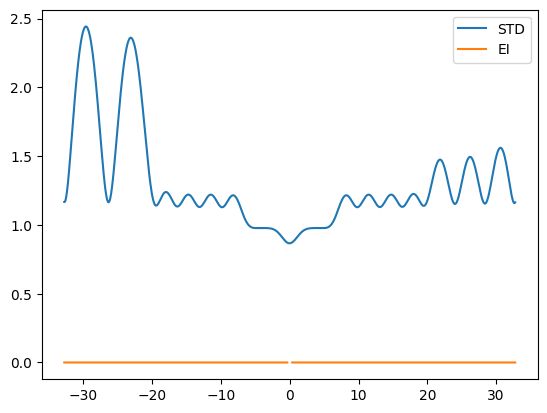

      EI:  44%|███████████████████████████████████▋                                             | 11/25 [00:05<00:08,  1.70it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


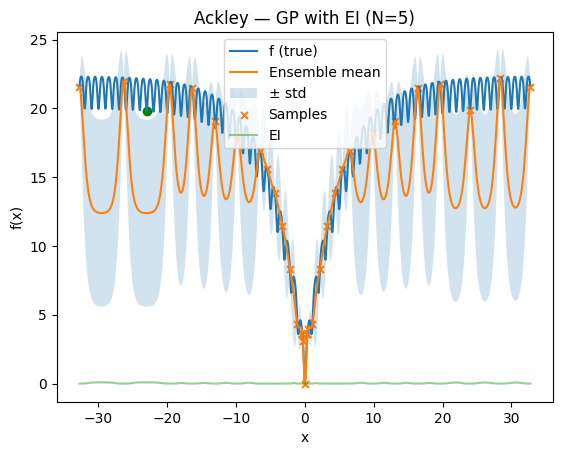

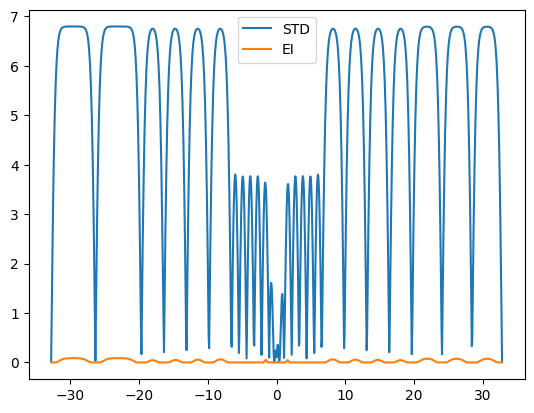

      EI:  48%|██████████████████████████████████████▉                                          | 12/25 [00:06<00:07,  1.63it/s]

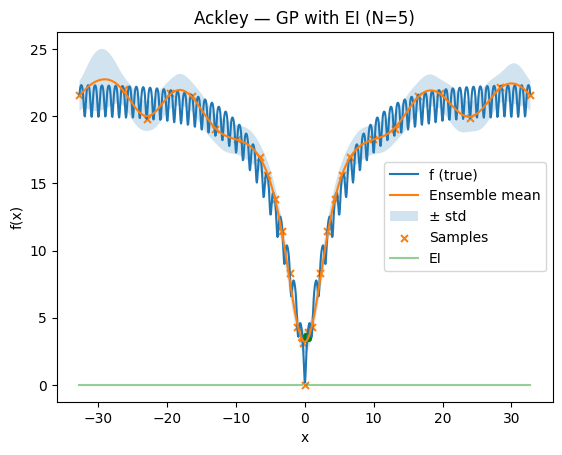

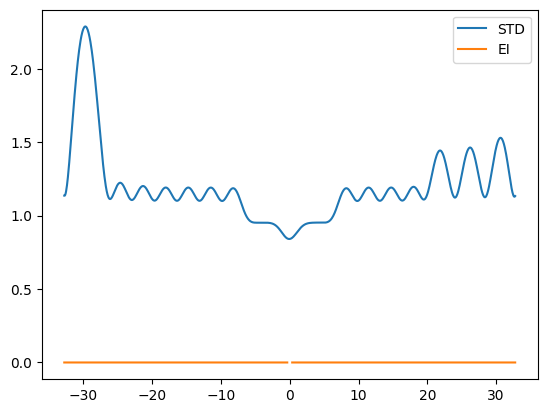

KeyboardInterrupt: 

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tabulate import tabulate
from typing import Dict, Tuple

# ============================================================================
# HETEROGENEITY METRICS
# ============================================================================

def compute_heterogeneity(gaps, N):
    """Compute gap heterogeneity metrics for a given set of gaps and N subdomains."""
    gaps = np.array(gaps, dtype=float)
    total = np.sum(gaps)

    if total == 0:
        return {
            'H_norm': 1.0, 'N_eff': float(N), 'rho': 1.0,
            'ratio': 1.0, 'n50': N // 2, 'n80': N
        }

    p = gaps / total
    H = -np.sum(p[p > 0] * np.log2(p[p > 0]))
    H_max = np.log2(N)
    H_norm = H / H_max if H_max > 0 else 1.0
    N_eff = 2 ** H
    rho = N_eff / N

    nonzero = gaps[gaps > 1e-10]
    if len(nonzero) > 0 and np.min(nonzero) > 0:
        ratio = np.max(gaps) / np.min(nonzero)
    else:
        ratio = float('inf')

    sorted_gaps = np.sort(gaps)[::-1]
    cumsum = np.cumsum(sorted_gaps)
    n50 = int(np.searchsorted(cumsum, 0.5 * total) + 1)
    n80 = int(np.searchsorted(cumsum, 0.8 * total) + 1)

    return {
        'H_norm': H_norm, 'N_eff': N_eff, 'rho': rho,
        'ratio': ratio, 'n50': n50, 'n80': n80
    }


# ============================================================================
# REPORTING FUNCTIONS
# ============================================================================

def print_heterogeneity_table(all_heterogeneity, func_order):
    """Print full heterogeneity table to console."""
    headers = ['Function', 'N', 'H/Hmax', 'N_eff', 'ρ', 'Ratio', 'n₅₀', 'n₈₀']
    rows = []
    for fname in func_order:
        if fname not in all_heterogeneity:
            continue
        for N in sorted(all_heterogeneity[fname].keys()):
            m = all_heterogeneity[fname][N]
            ratio_str = '∞' if m['ratio'] > 1e6 else f"{m['ratio']:.1f}×"
            rows.append([fname, N, f"{m['H_norm']:.3f}", f"{m['N_eff']:.2f}",
                         f"{m['rho']:.3f}", ratio_str, m['n50'], m['n80']])
        rows.append([''] * 8)

    print('\n' + '=' * 75)
    print('HETEROGENEITY METRICS — All functions × all N')
    print('=' * 75)
    print(tabulate(rows, headers=headers, tablefmt='simple', stralign='right'))


def print_best_N_table(all_heterogeneity, func_order):
    """Print best-N table (lowest rho per function)."""
    headers = ['Function', 'Best N', 'H/Hmax', 'N_eff', 'ρ', 'n₈₀']
    rows = []
    for fname in func_order:
        if fname not in all_heterogeneity:
            continue
        best_N = min(all_heterogeneity[fname],
                     key=lambda n: all_heterogeneity[fname][n]['rho'])
        m = all_heterogeneity[fname][best_N]
        rows.append([fname, best_N, f"{m['H_norm']:.3f}",
                     f"{m['N_eff']:.2f}", f"{m['rho']:.3f}", m['n80']])

    print('\n' + '=' * 65)
    print('BEST N PER FUNCTION (lowest ρ)')
    print('=' * 65)
    print(tabulate(rows, headers=headers, tablefmt='simple', stralign='right'))


def print_rmse_table(all_rmse, func_order, N_list):
    """Print RMSE results: for each function, show strategy × N × surrogate."""
    for fname in func_order:
        if fname not in all_rmse:
            continue
        print(f'\n{"=" * 90}')
        print(f'  {fname} — RMSE across N and strategies')
        print(f'{"=" * 90}')

        # Collect all strategies seen
        strat_surr_keys = set()
        for N in N_list:
            if N in all_rmse[fname]:
                strat_surr_keys.update(all_rmse[fname][N].keys())
        strat_surr_keys = sorted(strat_surr_keys)

        headers = ['Strategy', 'Surrogate'] + [f'N={N}' for N in N_list]
        rows = []
        for (strat, surr) in strat_surr_keys:
            row = [strat, surr]
            for N in N_list:
                if N in all_rmse[fname] and (strat, surr) in all_rmse[fname][N]:
                    row.append(f"{all_rmse[fname][N][(strat, surr)]:.4f}")
                else:
                    row.append('—')
            rows.append(row)

        print(tabulate(rows, headers=headers, tablefmt='simple', stralign='right'))


def print_combined_summary(all_heterogeneity, all_rmse, func_order, N_list,
                           target_strategy='STD * domain_weights', target_surrogate='GP'):
    """Print a combined table: heterogeneity + best RMSE for a chosen strategy across N."""
    headers = ['Function', 'N', 'ρ', 'n₈₀',
               f'RMSE ({target_strategy}, {target_surrogate})', 'Best N (ρ)', 'Best N (RMSE)']
    rows = []

    for fname in func_order:
        if fname not in all_heterogeneity:
            continue

        best_rho_N = min(all_heterogeneity[fname],
                         key=lambda n: all_heterogeneity[fname][n]['rho'])

        best_rmse_N = None
        best_rmse_val = float('inf')

        for N in N_list:
            if N not in all_heterogeneity.get(fname, {}):
                continue

            m = all_heterogeneity[fname][N]
            rmse_val = '—'
            if fname in all_rmse and N in all_rmse[fname]:
                key = (target_strategy, target_surrogate)
                if key in all_rmse[fname][N]:
                    rmse_val = f"{all_rmse[fname][N][key]:.4f}"
                    if all_rmse[fname][N][key] < best_rmse_val:
                        best_rmse_val = all_rmse[fname][N][key]
                        best_rmse_N = N

            rows.append([
                fname, N, f"{m['rho']:.3f}", m['n80'], rmse_val,
                best_rho_N if N == sorted(all_heterogeneity[fname].keys())[0] else '',
                best_rmse_N if N == sorted(all_heterogeneity[fname].keys())[-1] else ''
            ])
        rows.append([''] * 7)

    print('\n' + '=' * 100)
    print(f'COMBINED: Heterogeneity + RMSE ({target_strategy}, {target_surrogate})')
    print('=' * 100)
    print(tabulate(rows, headers=headers, tablefmt='simple', stralign='right'))


def generate_latex_tables(all_heterogeneity, all_rmse, func_order, N_list,
                          target_strategy='STD * domain_weights', target_surrogate='GP'):
    """Generate LaTeX source for heterogeneity + RMSE tables."""

    # --- Table 1: Full heterogeneity ---
    print('\n% --- LaTeX: Full heterogeneity table ---')
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    N_str = ', '.join([str(n) for n in N_list])
    print(r'\caption{Gap heterogeneity metrics for all benchmark functions at $N \in \{' + N_str + r'\}$.}')
    print(r'\label{tab:heterogeneity_vs_N}')
    print(r'\scriptsize')
    print(r'\setlength{\tabcolsep}{4pt}')
    print(r'\begin{tabular}{@{}lrrrrrrr@{}}')
    print(r'\toprule')
    print(r'\textbf{Function} & $N$ & $H/H_{\max}$ & $N_{\mathrm{eff}}$ & $\rho$ & $\Delta_{\max}/\Delta_{\min}$ & $n_{50}$ & $n_{80}$ \\')
    print(r'\midrule')

    for fname in func_order:
        if fname not in all_heterogeneity:
            continue
        first = True
        for N in sorted(all_heterogeneity[fname].keys()):
            m = all_heterogeneity[fname][N]
            ratio_str = r'$\infty$' if m['ratio'] > 1e6 else f"${m['ratio']:.1f}\\times$"
            name_col = fname.replace('_', r'\_') if first else ''
            print(f"{name_col:<16} & {N} & {m['H_norm']:.3f} & {m['N_eff']:.2f} & "
                  f"{m['rho']:.3f} & {ratio_str} & {m['n50']} & {m['n80']} \\\\")
            first = False
        print(r'\addlinespace')

    print(r'\bottomrule')
    print(r'\end{tabular}')
    print(r'\end{table}')

    # --- Table 2: RMSE across N for target strategy ---
    print(f'\n% --- LaTeX: RMSE across N for {target_strategy} ({target_surrogate}) ---')
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    N_header = ' & '.join([f'$N = {n}$' for n in N_list])
    print(r'\caption{RMSE for ' + target_strategy.replace('*', r'$\times$') +
          f' ({target_surrogate})' + r' across partition resolutions $N$.}')
    print(r'\label{tab:rmse_vs_N}')
    print(r'\small')
    print(r'\begin{tabular}{@{}l' + 'r' * len(N_list) + r'r@{}}')
    print(r'\toprule')
    print(r'\textbf{Function} & ' + N_header + r' & \textbf{Best $N$} \\')
    print(r'\midrule')

    for fname in func_order:
        if fname not in all_rmse:
            continue
        key = (target_strategy, target_surrogate)
        vals = []
        best_val = float('inf')
        best_N = '—'
        for N in N_list:
            if N in all_rmse[fname] and key in all_rmse[fname][N]:
                v = all_rmse[fname][N][key]
                vals.append(f'{v:.4f}')
                if v < best_val:
                    best_val = v
                    best_N = str(N)
            else:
                vals.append('—')
        val_str = ' & '.join(vals)
        display_name = fname.replace('_', r'\_')
        print(f'{display_name:<16} & {val_str} & {best_N} \\\\')

    print(r'\bottomrule')
    print(r'\end{tabular}')
    print(r'\end{table}')


# ============================================================================
# CONFIGURATION
# ============================================================================

DOMAIN_SPLITS_LIST = [5, 7, 10]  # N ∈ {5, 7, 9, 11, 13, 15, 17}

FUNC_ORDER = [
    'Langermann',
    'Forrester', 'GramacyLee', 'Levy1D',
    'Ackley', 'Griewank', 'Higdon', 'Schwefel', 'Eggholder1D', 'Michalewicz1D',
    'Sigmoid', 'Bukin1D',
]

surrogate = 'GP'
recompute_gaps = False
xi = 0.1

# --- Collectors ---
all_heterogeneity = {}   # {func_name: {N: metrics_dict}}
all_rmse = {}            # {func_name: {N: {(strategy, surrogate): rmse_float}}}
all_outputs = {}         # {func_name: {N: {(strategy, surrogate): preds}}}


# ============================================================================
# MAIN LOOP: functions × N × strategies
# ============================================================================

for func_name in FUNCTIONS.keys():
    selection = func_name

    if func_name in ['Langermann', 'Griewank']:
        OVERALL_BUDGET = 100
    else:
        OVERALL_BUDGET = 50

    sampling_budget = 0.5
    BUDGET = int(OVERALL_BUDGET * sampling_budget)
    REFINING = int(OVERALL_BUDGET * (1 - sampling_budget))

    GRID_EVAL = 10
    func = FUNCTIONS[selection]['f']()
    DOMAIN = FUNCTIONS[selection]['domain']
    DENSE_BUDGET = BUDGET * 2
    TEST_SAMPLE_SIZE = 2501 if BUDGET * 5 < 2501 else BUDGET * 5
    RANDOM_SEED = 0

    if func_name == "GramacyLee":
        DOMAIN = [0.5, 2.5]

    print('\n' + '=' * 70)
    print(f'  {func_name}')
    print(f'  BUDGET: {OVERALL_BUDGET} (warm start: {BUDGET}, refining: {REFINING})')
    print(f'  DOMAIN: {DOMAIN}')
    print('=' * 70)

    f = func.f
    X_grid = np.linspace(DOMAIN[0], DOMAIN[1], 1000).reshape(-1, 1)
    y_grid_true = f(X_grid)

    # Initialize collectors for this function
    all_heterogeneity[func_name] = {}
    all_rmse[func_name] = {}
    all_outputs[func_name] = {}

    # ------------------------------------------------------------------
    # LOOP OVER N (domain splits)
    # ------------------------------------------------------------------
    for DOMAIN_SPLITS in DOMAIN_SPLITS_LIST:
        DOMAIN_SPLITS = int(DOMAIN_SPLITS)
        DOMAIN_SPLITS_PC = 1.0 / DOMAIN_SPLITS

        print(f'\n  --- N = {DOMAIN_SPLITS} ---')

        # --- Warm-start sampling via McCormick gap allocation ---
        X_warm, y_warm, domains, gaps = method0_uncertanity(
            func, sample_coarse=False, mccormick_sampling=False
        )
        if recompute_gaps:
            gaps = compute_gaps(np.sort(X_warm))

        X_warm = X_warm.reshape((-1, 1))
        y_warm = y_warm.reshape((-1, 1))

        sample_dist = allocate_samples(gaps, BUDGET, MIN_SAMPLES)
        print(f'  Sample Allocations: {sample_dist}')
        print(f'  Gaps: {[f"{g:.4f}" for g in gaps]}')

        # --- Compute and store heterogeneity ---
        metrics = compute_heterogeneity(gaps, DOMAIN_SPLITS)
        all_heterogeneity[func_name][DOMAIN_SPLITS] = metrics
        print(f'  H/Hmax={metrics["H_norm"]:.3f}, N_eff={metrics["N_eff"]:.2f}, '
              f'rho={metrics["rho"]:.3f}, n50={metrics["n50"]}, n80={metrics["n80"]}')

        # --- Domain-filtered test set ---
        mask_threshold = 2
        if func_name in ['Langermann']:
            X_test_full = np.linspace(DOMAIN[0], DOMAIN[1], 1500)
        else:
            X_test_full = np.linspace(DOMAIN[0], DOMAIN[1], 1500)

        # Filter test points to domains with allocation > threshold
        final_mask = np.zeros_like(X_test_full, dtype=bool)
        for d, alloc in zip(domains, sample_dist):
            if alloc > mask_threshold:
                final_mask[np.logical_and(X_test_full >= d[0],
                                          X_test_full <= d[1])] = True
        X_test = X_test_full[final_mask]
        y_test = f(X_test)

        # --- Domain weights for gap-weighted strategies ---
        X_domains = assign_domains(X_grid, domains)
        X_grid_gaps = np.array(gaps)[X_domains.ravel()]
        domain_weights = (X_grid_gaps / sum(gaps)) * 100

        # --- Define strategies (must reference current domain_weights) ---
        strategies = [
            ('EI', lambda mu, std, f_best, xi_:
                expected_improvement(mu, std, f_best, xi=xi_)),
            ('EI (Std * domain_weights) ', lambda mu, std, f_best, xi_:
                expected_improvement(mu, std * domain_weights, f_best, xi=xi_)),
            ('STD', lambda mu, std, f_best, xi_: std),
            ('STD * domain_weights', lambda mu, std, f_best, xi_:
                std * domain_weights),
        ]

        # --- Collectors for this (func, N) ---
        rmse_N: Dict[Tuple[str, str], float] = {}
        preds_N: Dict[Tuple[str, str], np.ndarray] = {}

        # --- Envelope plot for this N ---
        boundaries = np.linspace(DOMAIN[0], DOMAIN[1], DOMAIN_SPLITS + 1)
        if recompute_gaps:
            L, U = piecewise_envelopes(func, X_grid, y_grid_true, np.sort(X_warm.ravel()))
        else:
            L, U = piecewise_envelopes(func, X_grid, y_grid_true, boundaries)

        fig_env = plt.figure(figsize=(8, 5))
        plt.plot(X_grid, y_grid_true, label=func_name)
        plt.plot(X_grid, L, c='orange', label='Under Est.')
        plt.plot(X_grid, U, c='green', label='Over Est.')
        plt.fill_between(X_grid.ravel(), L.ravel(), U.ravel(), alpha=0.08, color='gray')
        plt.scatter(X_warm, y_warm, s=25, marker='x', c='red', label='Warm-start samples')
        for b in boundaries[1:-1]:
            plt.axvline(b, color='gray', ls='--', lw=0.7, alpha=0.5)
        plt.title(f'{func_name} — N={DOMAIN_SPLITS}, ρ={metrics["rho"]:.3f}')
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.show()
        plt.close(fig_env)

        # ==============================================================
        # LOOP OVER STRATEGIES
        # ==============================================================
        for strategy, ei_func in strategies:

            experiment_name = f'{surrogate}+{strategy}+warm_start-N{DOMAIN_SPLITS}-B{BUDGET}'
            output_dir = f'./plots/it8/{func_name}_{experiment_name}'
            output_dir_plot = f'{output_dir}/sampling/'
            output_dir_ei = f'{output_dir}/ei/'
            os.makedirs(output_dir_plot, exist_ok=True)
            os.makedirs(output_dir_ei, exist_ok=True)

            print(f'    Strategy: {strategy}')

            # Fresh warm start for each strategy
            X, y, domains_s, gaps_s = method0_uncertanity(
                func, sample_coarse=False, mccormick_sampling=False
            )
            if recompute_gaps:
                gaps_s = compute_gaps(np.sort(X))
            X = X.reshape((-1, 1))
            y = y.reshape((-1, 1))

            # --- Iterative refinement ---
            n_add = REFINING
            for t in tqdm(range(int(n_add)), desc=f'      {strategy}', leave=False):
                if surrogate != 'NN':
                    ensemble = fit_gp(X, y)
                else:
                    ensemble = ImprovedMLP(K=2, n_ensemble=5)
                    ensemble.fit(X, y)

                mu, std = ensemble.predict(X_grid, return_std=True)
                f_best = np.min(y)
                std = np.maximum(std, 1e-12)
                ei = ei_func(mu, std, f_best, xi)

                idx = int(np.argmax(ei))
                x_next = X_grid[idx: idx + 1]

                # Avoid duplicates
                tries = 0
                while (np.min(np.abs(X - x_next)) < ((DOMAIN[1] - DOMAIN[0]) * 0.01)
                       and tries < 10):
                    ei[idx] = -np.inf
                    idx = int(np.argmax(ei))
                    x_next = X_grid[idx: idx + 1]
                    tries += 1

                y_next = f(x_next)

                # --- Sampling plot ---
                fig = plt.figure()
                plt.plot(X_grid, y_grid_true, label="f (true)")
                plt.plot(X_grid, mu, label="Ensemble mean")
                plt.fill_between(X_grid.ravel(), (mu - std), (mu + std),
                                 alpha=0.2, label="± std")
                plt.scatter(X, y, s=25, marker="x", label="Samples")
                plt.scatter(x_next, y_next, c='g')
                plt.plot(X_grid, ei, label=strategy, alpha=0.5)
                plt.title(f"{func_name} — {surrogate} with {strategy} (N={DOMAIN_SPLITS})")
                plt.xlabel("x"); plt.ylabel("f(x)")
                plt.legend(loc="best")
                plt.show()
                fig.savefig(f'{output_dir_plot}/frame_{t}.png')
                plt.close(fig)

                # --- EI/STD plot ---
                fig = plt.figure()
                plt.plot(X_grid, std, label='STD')
                plt.plot(X_grid, ei, label=strategy)
                plt.legend()
                plt.show()
                fig.savefig(f'{output_dir_ei}/frame_{t}.png')
                plt.close(fig)

                X = np.vstack([X, x_next])
                y = np.concatenate([y, y_next])

            # --- Evaluate GP surrogate ---
            mu, std = ensemble.predict(X_test.reshape((-1, 1)), return_std=True)
            rmse_gp = float(np.sqrt(mean_squared_error(y_test, np.array(mu).ravel())))
            rmse_N[(strategy, 'GP')] = rmse_gp
            preds_N[(strategy, 'GP')] = mu
            print(f'      GP RMSE: {rmse_gp:.4f}')

            # --- Evaluate NN surrogate on same samples ---
            ensemble_nn = ImprovedMLP(K=2, n_ensemble=5)
            ensemble_nn.fit(X, y)
            mu_nn, std_nn = ensemble_nn.predict(X_test.reshape((-1, 1)), return_std=True)
            rmse_nn = float(np.sqrt(mean_squared_error(y_test, np.array(mu_nn).ravel())))
            rmse_N[(strategy, 'NN')] = rmse_nn
            preds_N[(strategy, 'NN')] = mu_nn
            print(f'      NN RMSE: {rmse_nn:.4f}')

            # --- Final sample distribution plot ---
            fig = plt.figure(figsize=(10, 5))
            plt.plot(X_grid, y_grid_true, label=f"True {func_name}")
            plt.scatter(X, y, s=28, label=f"{strategy} samples (M={len(X)})",
                        zorder=5, c='r')
            plt.xlabel("x"); plt.ylabel("f(x)")
            plt.title(f"Approach A ({strategy}) — {surrogate}, N={DOMAIN_SPLITS}")
            plt.legend()
            plt.tight_layout()
            plt.show()
            fig.savefig(f'/Users/qazi/RWTH/Thesis2/presentation/plots/'
                        f'sample_analysis/{func_name}_{strategy}_{surrogate}_N{DOMAIN_SPLITS}_{len(X)}.png')
            plt.close(fig)

        # Store results for this (func, N)
        all_rmse[func_name][DOMAIN_SPLITS] = rmse_N
        all_outputs[func_name][DOMAIN_SPLITS] = preds_N


# ============================================================================
# POST-LOOP: Print all summary tables
# ============================================================================

func_order_available = [f for f in FUNC_ORDER if f in all_heterogeneity]
N_list = sorted(DOMAIN_SPLITS_LIST)

# --- Console tables ---
print_heterogeneity_table(all_heterogeneity, func_order_available)
print_best_N_table(all_heterogeneity, func_order_available)
print_rmse_table(all_rmse, func_order_available, N_list)

# --- Combined summary: heterogeneity + RMSE for STD×Gap (GP) ---
print_combined_summary(all_heterogeneity, all_rmse, func_order_available, N_list,
                       target_strategy='STD * domain_weights', target_surrogate='GP')

# --- LaTeX tables ---
generate_latex_tables(all_heterogeneity, all_rmse, func_order_available, N_list,
                      target_strategy='STD * domain_weights', target_surrogate='GP')

# --- Also print for EI×Gap (GP) ---
print_combined_summary(all_heterogeneity, all_rmse, func_order_available, N_list,
                       target_strategy='EI (Std * domain_weights) ', target_surrogate='GP')
generate_latex_tables(all_heterogeneity, all_rmse, func_order_available, N_list,
                      target_strategy='EI (Std * domain_weights) ', target_surrogate='GP')

In [22]:
# --- Combined summary: heterogeneity + RMSE for STD×Gap (GP) ---
print_combined_summary(all_heterogeneity, all_rmse, func_order_available, N_list,
                       target_strategy='STD * domain_weights', target_surrogate='NN')

# --- LaTeX tables ---
generate_latex_tables(all_heterogeneity, all_rmse, func_order_available, N_list,
                      target_strategy='STD * domain_weights', target_surrogate='NN')

# --- Also print for EI×Gap (GP) ---
print_combined_summary(all_heterogeneity, all_rmse, func_order_available, N_list,
                       target_strategy='EI (Std * domain_weights) ', target_surrogate='NN')
generate_latex_tables(all_heterogeneity, all_rmse, func_order_available, N_list,
                      target_strategy='EI (Std * domain_weights) ', target_surrogate='NN')


COMBINED: Heterogeneity + RMSE (STD * domain_weights, NN)
     Function    N      ρ    n₈₀    RMSE (STD * domain_weights, NN)    Best N (ρ)    Best N (RMSE)
-------------  ---  -----  -----  ---------------------------------  ------------  ---------------
   Langermann    5  0.519      2                             0.3551            11
   Langermann    7  0.434      2                             0.1587
   Langermann   10  0.404      3                             0.2460
   Langermann   11  0.400      4                             0.2304                              7

    Forrester    5  0.636      2                             0.2277             7
    Forrester    7  0.607      3                             0.2359
    Forrester   10  0.632      4                             0.1476
    Forrester   11  0.685      5                             0.1869                             10

   GramacyLee    5  0.945      4                             0.0245            11
   GramacyLee    7  0.938